# Peak Phases Forest Plot

Python reproduction of the `results-phase-plot` chunk in `ThesisDraft_v2.Rmd`.

- Per-region posterior of the annual-cycle peak week, relative to the New Year.
- `peak_wk = atan2(gamma, beta) * 52/(2*pi)`
- Circular mean via the direction-vector trick so wrap-around at the 52-week boundary is handled.
- 95% CI from re-centred samples (quantile type 7, matching R's default and numpy's linear method).
- Forest plot: black points = posterior means, bars = 95% CI, blue band = winter (New Year +/- 2 months).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV = "../data/models/wide_weekly_scaledPer10k/v2.8/raw_samples.csv"

regions = [
    "HSE Dublin and Midlands", "HSE Dublin and North East",
    "HSE Dublin and South East", "HSE Mid West",
    "HSE South West", "HSE West and North West",
]

raw = pd.read_csv(CSV)

In [2]:
# Wrap any week value into (-26, 26] -- the year is a 52-week circle.
def wrap52(x):
    return ((x + 26) % 52) - 26


def phase_stats(i):
    """Posterior peak-week stats for region i (1-indexed, matching the JAGS params)."""
    b = raw[f"beta[{i}]"].to_numpy()
    g = raw[f"gamma[{i}]"].to_numpy()
    peak = wrap52(np.arctan2(g, b) * 52 / (2 * np.pi))
    # circular mean direction (in weeks)
    mean_dir = np.arctan2(np.mean(np.sin(2 * np.pi * peak / 52)),
                          np.mean(np.cos(2 * np.pi * peak / 52))) * 52 / (2 * np.pi)
    shifted = wrap52(peak - mean_dir)  # samples re-centred on mean
    q_lo, q_hi = np.quantile(shifted, [0.025, 0.975])  # linear == R type 7
    return {
        "region": regions[i - 1],
        "mean_pk": mean_dir,
        "ci_lo": mean_dir + q_lo,
        "ci_hi": mean_dir + q_hi,
        "width": q_hi - q_lo,
        "p_2mo": np.mean(np.abs(peak) <= 52 / 12 * 2),
    }


phase_tab = pd.DataFrame([phase_stats(i) for i in range(1, len(regions) + 1)])
phase_tab = phase_tab.sort_values("region").reset_index(drop=True)
phase_tab

,region,mean_pk,ci_lo,ci_hi,width,p_2mo
0,HSE Dublin and Midlands,4.833536,0.095076,9.707319,9.612243,0.943488
1,HSE Dublin and North East,1.403793,-2.123786,5.004064,7.127850,0.999737
2,HSE Dublin and South East,1.568772,-2.264081,5.509603,7.773684,0.999075
3,HSE Mid West,19.069474,-2.901735,41.049847,43.951582,0.164100
4,HSE South West,2.288687,-2.369570,7.101008,9.470578,0.993125
5,HSE West and North West,4.721558,-7.304304,17.349529,24.653833,0.764537


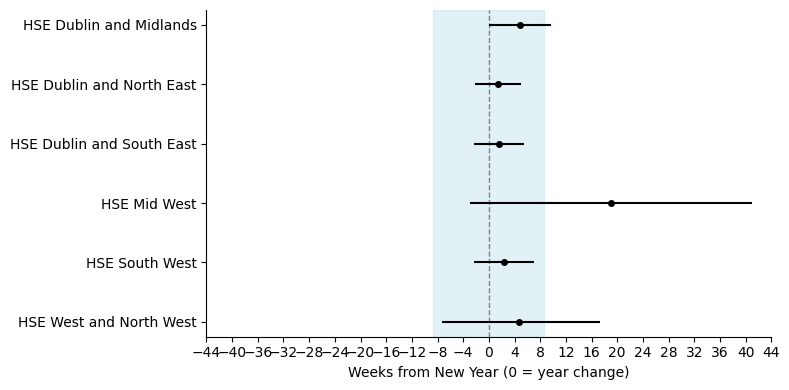

In [3]:
xmax = np.ceil(np.max(np.abs(np.r_[phase_tab["ci_lo"], phase_tab["ci_hi"]])) / 4) * 4
winter = 52 / 12 * 2  # +/- 2 months from the New Year, in weeks

# Top-to-bottom order matches the Rmd: regions alphabetical, first at the top.
order = list(phase_tab["region"])
y_pos = np.arange(len(order))[::-1]  # row 0 at top

fig, ax = plt.subplots(figsize=(8, 4))
ax.axvspan(-winter, winter, color="lightblue", alpha=0.35, zorder=0)
ax.axvline(0, linestyle="--", color="grey", linewidth=1, zorder=1)

ax.errorbar(
    phase_tab["mean_pk"], y_pos,
    xerr=[phase_tab["mean_pk"] - phase_tab["ci_lo"],
          phase_tab["ci_hi"] - phase_tab["mean_pk"]],
    fmt="o", color="black", ecolor="black", capsize=0, markersize=4, zorder=2,
)

ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_xticks(np.arange(-xmax, xmax + 1, 4))
ax.set_xlim(-xmax, xmax)
ax.set_xlabel("Weeks from New Year (0 = year change)")
ax.set_ylabel(None)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

In [ ]:
# Table equivalent of results-phase-table
table = pd.DataFrame({
    "Region": phase_tab["region"],
    "Mean peak (wk from NY)": phase_tab["mean_pk"].round(1),
    "95% CI (wk from NY)": [f"[{lo:+.1f}, {hi:+.1f}]"
                            for lo, hi in zip(phase_tab["ci_lo"], phase_tab["ci_hi"])],
    "P(NY +/- 2 mo)": phase_tab["p_2mo"].round(3),
})
table